In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib as mpl
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from datetime import datetime

import argparse
import os
from ast import literal_eval

import fsspec
import numpy as np
import pandas as pd
import xarray as xr
import goes2go
import pandas as pd
from tqdm import tqdm

In [2]:
GOES_EAST_COORDS = (-75.0, 0.0)  # Longitude, Latitude
GOES_WEST_COORDS = (-137.0, 0.0)  # Longitude, Latitude
HIMAWARI_COORDS = (140.7, 35.5)  # Longitude, Latitude

fov_bounds = {
    'GOES-East': {
        'lon_min': GOES_EAST_COORDS[0] - 60,
        'lon_max': GOES_EAST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'GOES-West': {
        'lon_min': GOES_WEST_COORDS[0] - 60,
        'lon_max': GOES_WEST_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    },
    'Himawari': {
        'lon_min': HIMAWARI_COORDS[0] - 60,
        'lon_max': HIMAWARI_COORDS[0] + 60,
        'lat_min': -60.0,
        'lat_max': 60.0
    }
}

## HIMAWARI

In [4]:
df_him = pd.read_csv('/home/users/annaju/eo-tools/scripts/files/matched-ibtracs-himawari-[2023-2025].csv')
df_him_vars = pd.read_csv('/home/users/annaju/eo-tools/scripts/files/matched-himawari-[2023-2025]-with-additional-variables.csv')

In [5]:
df_him_vars["ahi_file"] = df_him_vars["ahi_file"].apply(
    lambda x: literal_eval(x) if pd.notna(x) else x
)

#### Quality Filtering - Interpolated Tracks

These four storms have some issues in them, with the longitude crossing, we will filter them out for now:
- 2023213N14257
- 2023055S14184
- 2023059S15149
- 2023316S08168

Text(0, 0.5, 'Latitude')

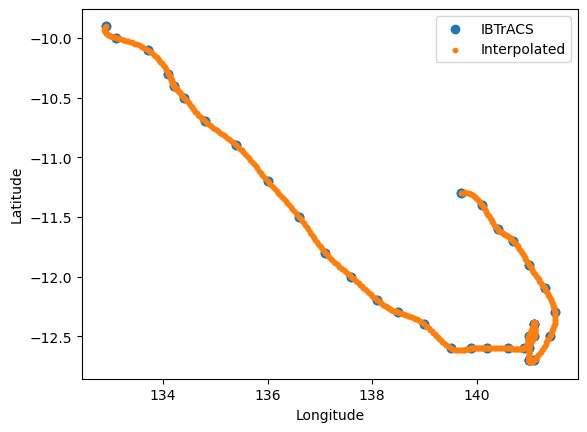

In [18]:
random_storm = np.random.choice(df_him.SID.unique())
# random_storm = '2023213N14257'

plt.scatter(df_him[df_him.SID == random_storm].LON, df_him[df_him.SID == random_storm].LAT, label='IBTrACS')
plt.scatter(df_him_vars[df_him_vars.SID == random_storm].LON, df_him_vars[df_him_vars.SID == random_storm].LAT, s=10, label='Interpolated')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

#### Quality Filtering - FOV

It seems that 3 storms have coordinates outside the FOV, we will also remove these:
- 2024012S09093
- 2023334N08088
- 2025331N07081

In [43]:
df_him_vars[df_him_vars.LON<fov_bounds['Himawari']['lon_min']].SID.unique()

array(['2024012S09093', '2023334N08088', '2025331N07081'], dtype=object)

In [44]:
df_him_vars[df_him_vars.LON>fov_bounds['Himawari']['lon_max']].SID.unique()

array([], dtype=object)

### Quality Filtering

In [45]:
problematic_storms = ['2023213N14257', '2023055S14184', '2023059S15149', '2023316S08168', '2024012S09093', '2023334N08088', '2025331N07081']

df_him = df_him[~df_him.SID.isin(problematic_storms)]
df_him_vars = df_him_vars[~df_him_vars.SID.isin(problematic_storms)]

In [46]:
lengths = df_him_vars['ahi_file'].apply(lambda x: len(x))

In [47]:
df_him_vars_all = df_him_vars[df_him_vars['all_available']]
df_him_vars_ahi = df_him_vars[lengths>16]

In [48]:
print(f'Total number of timesteps queried: {len(df_him_vars)}')
print(f'Total number of timesteps with ahi files: {len(df_him_vars_ahi)}')
print(f'Total number of timesteps without ahi files: {np.count_nonzero(lengths<16)}')
print(f'Total number of timesteps with all files available: {len(df_him_vars_all)}')


Total number of timesteps queried: 102842
Total number of timesteps with ahi files: 97319
Total number of timesteps without ahi files: 5523
Total number of timesteps with all files available: 75983


In [49]:
print(f'Number of storms in IBTrACs file: {len(df_him.SID.unique())}')
print(f'Number of storms with ahi files: {len(df_him_vars_ahi.SID.unique())}')
print(f'Number of storms without ahi files: {len(df_him_vars[lengths<16].SID.unique())}')
print(f'Number of storms with all files available: {len(df_him_vars_all.SID.unique())}')

Number of storms in IBTrACs file: 104
Number of storms with ahi files: 100
Number of storms without ahi files: 104
Number of storms with all files available: 82


### Visualization

In [50]:
storms_with_ahi = df_him_vars_ahi.SID.unique()
storms_with_all = df_him_vars_all.SID.unique()
storms_without_all = df_him_vars_ahi[~df_him_vars_ahi.SID.isin(storms_with_all)]

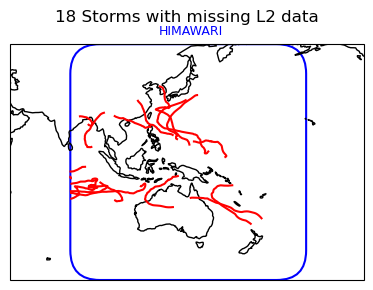

In [53]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(20, 3),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.set_extent([50, 230, -60, 60], crs=ccrs.PlateCarree())


# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)

# grouped = df_him_vars_ahi.groupby('SID')
# for i, (name, group) in enumerate(grouped):
#     ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='blue')

# grouped = df_him_vars_all.groupby('SID')
# for i, (name, group) in enumerate(grouped):
#     ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='red')

grouped = storms_without_all.groupby('SID')
for i, (name, group) in enumerate(grouped):
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='red')

# Draw Field of View boxes
from matplotlib.patches import FancyBboxPatch

patch = FancyBboxPatch(
    (fov_bounds['Himawari']['lon_min'], fov_bounds['Himawari']['lat_min']),
    fov_bounds['Himawari']['lon_max'] - fov_bounds['Himawari']['lon_min'],
    fov_bounds['Himawari']['lat_max'] - fov_bounds['Himawari']['lat_min'],
    boxstyle="round,pad=0,rounding_size=15",  # rounding_size in degrees
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
    edgecolor='blue',
    facecolor='none',
)
ax.add_patch(patch)

ax.text((fov_bounds['Himawari']['lon_min'] + fov_bounds['Himawari']['lon_max']) / 2 - 15, fov_bounds['Himawari']['lat_max'] + 5, 'HIMAWARI', transform=ccrs.PlateCarree(), fontsize=9, color='Blue')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
ax.set_title(
    "18 Storms with missing L2 data",
    y=1.06,      # higher than default
    pad=6,       # extra point spacing above axes
    loc="center"
)

plt.tight_layout()

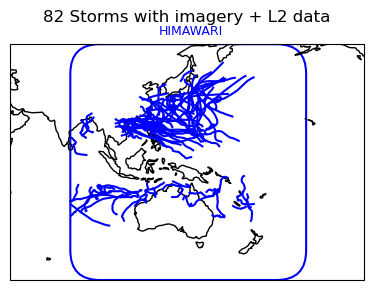

In [55]:
# Plot tracks on map
fig, ax = plt.subplots(figsize=(20, 3),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ax.set_global()
ax.add_feature(cfeature.COASTLINE, edgecolor='black')
ax.set_extent([50, 230, -60, 60], crs=ccrs.PlateCarree())


# plot every track with colour for category
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=-2, vmax=5)

# grouped = df_him_vars_ahi.groupby('SID')
# for i, (name, group) in enumerate(grouped):
#     ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='blue')

grouped = df_him_vars_all.groupby('SID')
for i, (name, group) in enumerate(grouped):
    ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='blue')

# grouped = storms_without_all.groupby('SID')
# for i, (name, group) in enumerate(grouped):
#     ax.plot(group['LON'], group['LAT'], transform=ccrs.PlateCarree(), label=name, color='red')

# Draw Field of View boxes
from matplotlib.patches import FancyBboxPatch

patch = FancyBboxPatch(
    (fov_bounds['Himawari']['lon_min'], fov_bounds['Himawari']['lat_min']),
    fov_bounds['Himawari']['lon_max'] - fov_bounds['Himawari']['lon_min'],
    fov_bounds['Himawari']['lat_max'] - fov_bounds['Himawari']['lat_min'],
    boxstyle="round,pad=0,rounding_size=15",  # rounding_size in degrees
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
    edgecolor='blue',
    facecolor='none',
)
ax.add_patch(patch)

ax.text((fov_bounds['Himawari']['lon_min'] + fov_bounds['Himawari']['lon_max']) / 2 - 15, fov_bounds['Himawari']['lat_max'] + 5, 'HIMAWARI', transform=ccrs.PlateCarree(), fontsize=9, color='Blue')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for ScalarMappable with colorbar
ax.set_title(
    "82 Storms with imagery + L2 data",
    y=1.06,      # higher than default
    pad=6,       # extra point spacing above axes
    loc="center"
)

plt.tight_layout()

In [56]:
df_him_vars_all.to_csv('matched-filtered-himawari-[2023-2025]-with-additional-variables.csv')

## GOES

In [57]:
df_geast = pd.read_csv('./files/matched-ibtracs-goes-east-[2023-2025].csv')
df_gwest = pd.read_csv('./files/matched-ibtracs-goes-west-[2023-2025].csv')

df_geast_vars = pd.read_csv('matched-goes-east-[2023-2025]-with-additional-variables.csv')
df_gwest_vars = pd.read_csv('matched-goes-west-[2023-2025]-with-additional-variables.csv')

In [59]:
df_geast_vars_all = df_geast_vars[df_geast_vars['all_available']]
df_gwest_vars_all = df_gwest_vars[df_gwest_vars['all_available']]

In [70]:
np.count_nonzero(df_geast_vars['abi_file'].isna()), np.count_nonzero(df_gwest_vars['abi_file'].isna())
# We don't really expect there to be many rows that don't have abi_files, since we already filtered for all available files in interpolate_goes_tcs.py

(np.int64(1), np.int64(0))

In [71]:
print('GOES EAST ------------------')
print(f'Total number of timesteps queried: {len(df_geast_vars)}')
print(f'Total number of timesteps with abi files: {len(df_geast_vars) - np.count_nonzero(df_geast_vars["abi_file"].isna())}')
print(f'Total number of timesteps without abi files: {np.count_nonzero(df_geast_vars["abi_file"].isna())}')
print(f'Total number of timesteps with all files available: {len(df_geast_vars_all)}')


print('GOES WEST ------------------')
print(f'Total number of timesteps queried: {len(df_gwest_vars)}')
print(f'Total number of timesteps with abi files: {len(df_gwest_vars) - np.count_nonzero(df_gwest_vars["abi_file"].isna())}')
print(f'Total number of timesteps without abi files: {np.count_nonzero(df_gwest_vars["abi_file"].isna())}')
print(f'Total number of timesteps with all files available: {len(df_gwest_vars_all)}')

GOES EAST ------------------
Total number of timesteps queried: 56022
Total number of timesteps with abi files: 56021
Total number of timesteps without abi files: 1
Total number of timesteps with all files available: 55376
GOES WEST ------------------
Total number of timesteps queried: 39901
Total number of timesteps with abi files: 39901
Total number of timesteps without abi files: 0
Total number of timesteps with all files available: 39771


In [72]:
print('GOES EAST ------------------')
print(f'Number of storms in IBTrACs file: {len(df_geast.SID.unique())}')
print(f'Number of files with ABI data: {len(df_geast_vars.SID.unique())}')
print(f'Number of storms with all files available: {len(df_geast_vars_all.SID.unique())}')

print('GOES WEST ------------------')
print(f'Number of storms in IBTrACs file: {len(df_gwest.SID.unique())}')
print(f'Number of files with ABI data: {len(df_gwest_vars.SID.unique())}')
print(f'Number of storms with all files available: {len(df_gwest_vars_all.SID.unique())}')

GOES EAST ------------------
Number of storms in IBTrACs file: 55
Number of files with ABI data: 55
Number of storms with all files available: 54
GOES WEST ------------------
Number of storms in IBTrACs file: 45
Number of files with ABI data: 45
Number of storms with all files available: 45


#### Quality Filtering - Interpolated Tracks All Look Good

#### Quality Filtering - FOV All Look Good

In [79]:
print(df_geast_vars[df_geast_vars.LON<fov_bounds['GOES-East']['lon_min']].SID.unique())
print(df_geast_vars[df_geast_vars.LON>fov_bounds['GOES-East']['lon_max']].SID.unique())

print(df_gwest_vars[df_gwest_vars.LON<fov_bounds['GOES-West']['lon_min']].SID.unique())
print(df_gwest_vars[df_gwest_vars.LON>fov_bounds['GOES-West']['lon_max']].SID.unique())

[]
[]
[]
[]


In [80]:
df_geast_vars_all.to_csv('matched-filtered-goes-east-[2023-2025]-with-additional-variables.csv')
df_gwest_vars_all.to_csv('matched-filtered-goes-west-[2023-2025]-with-additional-variables.csv')